## Case - Employee Score vs. Employee Background


### Background

- Here, we have internal company data that records each employee's performance appraisal score (`emp-score`).

- We want to understand more than just the relationship between hours worked (emp-hours) and performance score (`emp-score`) 

- we have other variables that are hypothetically related to those scores.

- First, let's assume we want to understand how the variable of education level (`emp-degree`) relates to employee performance scores (`emp-score`).

- We need to import library and function that need to run the code in this notebook to:
    - load data
    - doing simulation
    - drawing graph and other visualization

In [1]:
# load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
emp = pd.read_csv('employee_performance_dataset.csv')
emp.head()

,emp_score,emp_degree,emp_experience,emp_hours,emp_age
0,84.0,1,30,7.0,58
1,100.0,1,29,11.6,48
2,88.2,1,4,9.9,56
3,82.0,1,29,8.8,51
4,69.9,1,24,5.2,23


In [3]:
emp.isnull().sum()

emp_score         0
emp_degree        0
emp_experience    0
emp_hours         0
emp_age           0
dtype: int64

- Visualize emp_score and emp_hours to detect whether there's a potential unique pattern

In [4]:
emp.describe()

,emp_score,emp_degree,emp_experience,emp_hours,emp_age
count,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,79.867454,0.683333,15.259259,7.995185,38.984722
std,12.541678,0.465284,8.805889,2.337024,12.452159
min,51.900000,0.000000,0.000000,4.000000,18.000000
25%,69.700000,0.000000,8.000000,5.900000,28.000000
50%,78.300000,1.000000,16.000000,8.100000,39.000000
75%,90.725000,1.000000,23.000000,10.000000,50.000000
max,100.000000,1.000000,30.000000,12.000000,60.000000


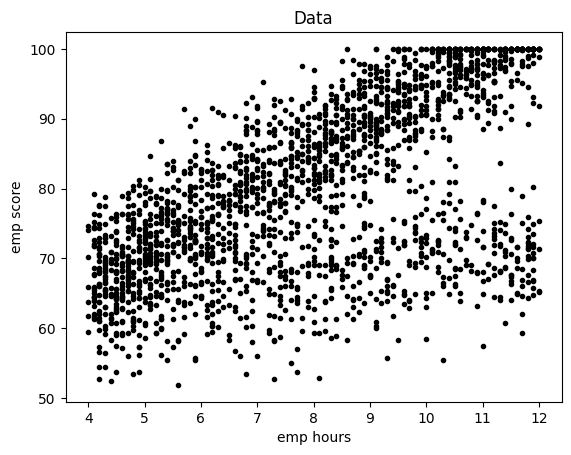

In [5]:
x = emp['emp_hours']
y = emp['emp_score']

plt.scatter(x, y, marker=".", color="k")
plt.xlabel("emp hours")
plt.ylabel("emp score")
plt.title("Data")
plt.show()

### Fit Linear Regression - Using a Continuous Variable

Use `ols` function under `statsmodels` library.

In [6]:
def print_coef_std_err(results):
    coef = results.params
    std_err = results.bse
    df = pd.DataFrame(data=np.transpose([coef, std_err]),
                      index=coef.index,
                      columns=["coef", "std err"])
    return df

In [7]:
# Create OLS model object
model = smf.ols("emp_score ~ emp_hours", data=emp)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_emp = print_coef_std_err(results)
results_emp

,coef,std err
Intercept,54.197587,0.771045
emp_hours,3.210666,0.092567


In [8]:
np.round(np.mean(emp['emp_hours']),1)

np.float64(8.0)

- Visualize the data and regression line

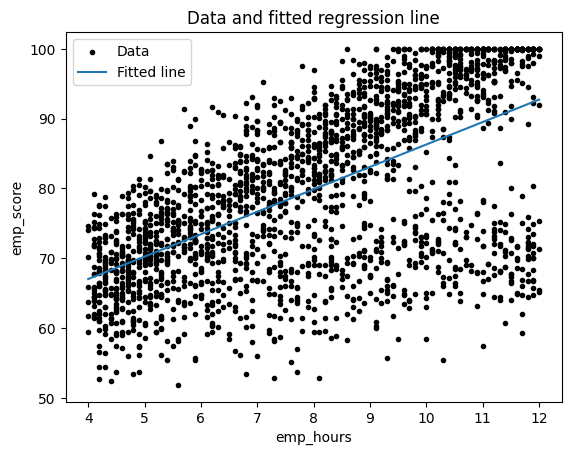

In [9]:
predictor = "emp_hours"
outcome = "emp_score"
data = emp.copy()
results_ = results_emp.copy()

plt.scatter(data[predictor], data[outcome], marker=".", label="Data", color="k")

a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)
fitted_values = a_hat + b_hat * x_domain

plt.plot(x_domain, fitted_values, label="Fitted line")
plt.legend()
plt.xlabel(predictor)
plt.ylabel(outcome)
plt.title("Data and fitted regression line")
plt.show()

### Coefficient Interpretation

In [10]:
results_emp

,coef,std err
Intercept,54.197587,0.771045
emp_hours,3.210666,0.092567


$$\text{emp\_score} = 54.20 + 3.21\text{emp\_hours}$$

- This value indicates that if an employee does not work at all or works zero hours (`emp_hours = 0`), then the estimated baseline performance score (`emp-score`) is **54.20**. This can be considered a baseline score without the influence of working hours.

- This value indicates a positive relationship between working hours and performance scores. Specifically, for every additional hour worked, the employee's performance score (`emp-score`) is predicted to increase by 3.21 points.

### Fit Linear Regression - Using a Binary Variable

In [11]:
# Create OLS model object
model = smf.ols("emp_score ~ emp_degree", data=emp)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_emp_bin = print_coef_std_err(results)
results_emp_bin

,coef,std err
Intercept,67.815205,0.362718
emp_degree,17.637438,0.438786


- Visualize the data and regression line

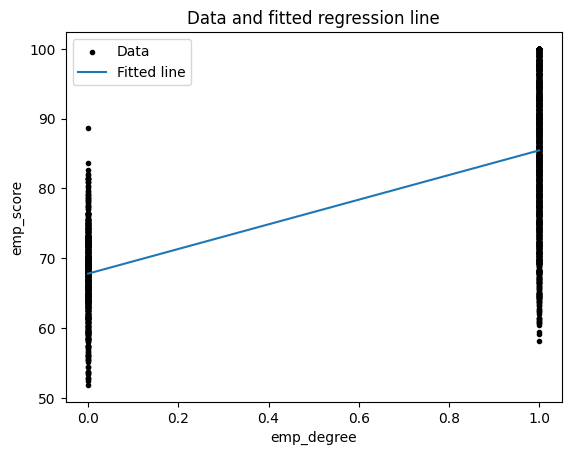

In [12]:
predictor = "emp_degree"
outcome = "emp_score"
data = emp.copy()
results_ = results_emp_bin.copy()

plt.scatter(data[predictor], data[outcome], marker=".", label="Data", color="k")

a_hat = results_.loc["Intercept"]["coef"]
b_hat = results_.loc[predictor]["coef"]

x_domain = np.linspace(np.min(data[predictor]), np.max(data[predictor]), 10000)
fitted_values = a_hat + b_hat * x_domain

plt.plot(x_domain, fitted_values, label="Fitted line")
plt.legend()
plt.xlabel(predictor)
plt.ylabel(outcome)
plt.title("Data and fitted regression line")
plt.show()

### Coefficient Interpretation

In [13]:
results_emp_bin

,coef,std err
Intercept,67.815205,0.362718
emp_degree,17.637438,0.438786


$$\text{emp\_score} = 67.81 + 17.63\text{emp\_degree}$$

- This value indicates that if an employee has no educational degree at all or the degree variable is zero ($\text{emp\_degree} = 0$), then the estimated baseline performance score ($\text{emp\_score}$) is 67.81. This can be considered a baseline score without the influence of educational level. 
- This value indicates a positive relationship between educational level and performance score. Specifically, for every one-unit increase in educational level ($\text{emp\_degree}$), the employee's performance score ($\text{emp\_score}$) is predicted to increase by 17.63 points.

### Fit Linear Regression (Multiple: emp_hours + emp_degree)

- We want to predict employee score from both hours work and an indivator for whether the employee degree
- Use `+` to add another predictors in the model

In [14]:
model = smf.ols("emp_score ~ emp_hours + emp_degree", data=emp)
results = model.fit()
results_emp_exp = print_coef_std_err(results)
results_emp_exp

,coef,std err
Intercept,43.270731,0.501277
emp_hours,3.109427,0.056209
emp_degree,17.175037,0.282325


$$\text{emp\_score} = 43.270 + 3.11\text{emp\_hours} + 17.17\text{emp\_degree}$$

- **Intercept**: The model predicts a score  of **43.27** for an individual with a score of 0 for hours worked (`emp_hours`) and no degree (`emp_degree`).

- **Employee Degree Coefficient** (`emp_degree`): If we compare two individuals with the same number of hours worked (`emp_hours`) but differing in degree holdings, the expected difference in scores is **17.17**.

- **Working Hours Coefficient** (`emp_hours`): If we compare two individuals with the same degree status (`emp_degree`) but differing by 1 unit of work hours, the expected difference in scores is **3.11**.

- Visualize the model with one continuous and one binary predictor simply by ploting two lines belong to each subpopulation
- In this case, we plot *two lines* representh the regression line of the employee whose have **not degree** an the othe regression with have **degree**

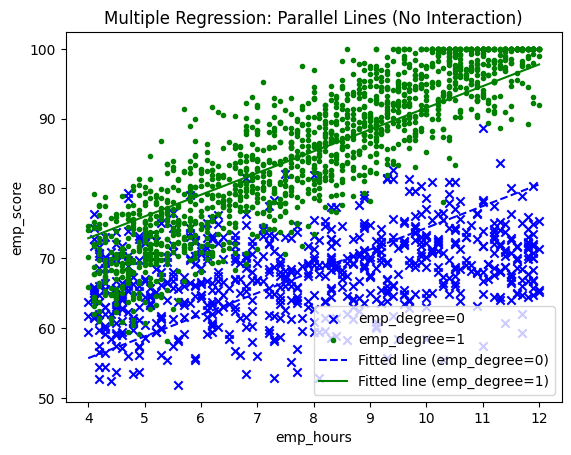

In [15]:
predictors = ["emp_hours", "emp_degree"]
outcome = "emp_score"
data = emp.copy()
results_ = results_emp_exp.copy()
linestyles = {0: "--", 1: "-"}
c = {0: "b", 1: "g"}
markers = {0: "x", 1: "."}

for i in range(2):
    plt.scatter(data[data[predictors[1]]==i][predictors[0]],
                data[data[predictors[1]]==i][outcome],
                color=c[i], marker=markers[i], label=f"emp_degree={i}")

x_domain = np.linspace(np.min(data[predictors[0]]), np.max(data[predictors[0]]), 100)
beta0_hat = results_.loc["Intercept"]["coef"]
beta1_hat = results_.loc[predictors[0]]["coef"]
beta2_hat = results_.loc[predictors[1]]["coef"]

fitted_values = [beta0_hat + beta1_hat * x_domain + beta2_hat * i for i in range(2)]

for i in range(2):
    plt.plot(x_domain, fitted_values[i], c=c[i],
             label=f"Fitted line (emp_degree={i})", linestyle=linestyles[i])

plt.legend()
plt.ylabel(outcome)
plt.xlabel(predictors[0])
plt.title("Multiple Regression: Parallel Lines (No Interaction)")
plt.show()

- Based on the figure, the slope of the regression model between employee score (`emp_score`) and hours worked (`emp_hours`) is identical or parallel for both subgroups (with and without degrees).
- However, if we examine the data distribution in the graph, we see that the trend or slope of the data points actually shows a significant difference between the `emp_degree=0` and `emp_degree=1` groups.
- To address this, we need to include an interaction variable between `emp_degree` and `emp_hours`, which is the product of the two variables, as a new predictor.
- This step will allow the model to have a different slope for each subgroup, thus more accurately representing the original data.

### Fit Linear Regression - Include an Interaction

By adding the interaction term `emp_degree:emp_hours`, the slope of `emp_hours` may **differ** between groups.

$$y = \beta_0 + \beta_1 \cdot emp\_hours + \beta_2 \cdot emp\_degree + \beta_3 \cdot (emp\_degree \times emp\_hours)$$

- `emp_degree = 0` → slope = $\beta_1$
- `emp_degree = 1` → slope = $\beta_1 + \beta_3$

If $\beta_3$ is significant → **there is an interaction → the two lines are not parallel!**

In [16]:
model = smf.ols("emp_score ~ emp_hours + emp_degree + emp_degree:emp_hours", data=emp)
results = model.fit()
results_emp_exp_inter = print_coef_std_err(results)
results_emp_exp_inter

,coef,std err
Intercept,60.423321,0.649994
emp_hours,0.936444,0.078798
emp_degree,-8.701833,0.799675
emp_degree:emp_hours,3.257786,0.096482


- Visualize the data and regression line

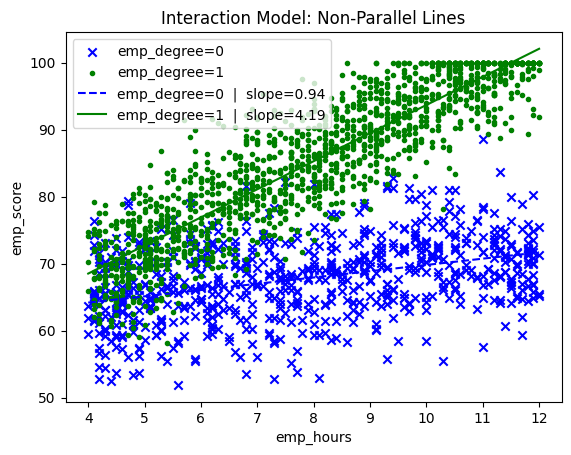

In [ ]:
predictors = ['emp_hours', 'emp_degree', 'emp_degree:emp_hours']
outcome = "emp_score"
data = emp.copy()
results_ = results_emp_exp_inter.copy()
linestyles = {0: "--", 1: "-"}
c = {0: "b", 1: "g"}
markers = {0: "x", 1: "."}

for i in range(2):
    plt.scatter(data[data[predictors[1]]==i][predictors[0]],
                data[data[predictors[1]]==i][outcome],
                color=c[i], marker=markers[i], label=f"emp_degree={i}")

beta0_hat = results_.loc["Intercept"]["coef"]
beta1_hat = results_.loc[predictors[0]]["coef"]
beta2_hat = results_.loc[predictors[1]]["coef"]
beta3_hat = results_.loc[predictors[2]]["coef"]

x_domain = np.linspace(np.min(data[predictors[0]]), np.max(data[predictors[0]]), 100)

fitted_values = [beta0_hat + beta1_hat * x_domain + beta2_hat * i + beta3_hat * i * x_domain
                 for i in range(2)]

for i in range(2):
    slope_i = beta1_hat + beta3_hat * i
    plt.plot(x_domain, fitted_values[i], c=c[i],
             label=f"emp_degree={i}  |  slope={slope_i:.2f}",
             linestyle=linestyles[i])

plt.legend()
plt.ylabel(outcome)
plt.xlabel(predictors[0])
plt.title("Interaction Model: Non-Parallel Lines")
plt.show()

- The slope differ between the two groups in the model that include interaction

In [18]:
print("=== Without Interaction ===")
print(results_emp_exp)
print()
print("=== With Interaction ===")
print(results_emp_exp_inter)
print()
b1 = results_emp_exp_inter.loc['emp_hours','coef']
b3 = results_emp_exp_inter.loc['emp_degree:emp_hours','coef']
print("Interpretasi Interaksi:")
print(f"  Slope emp_hours to emp_degree=0 : {b1:.4f}")
print(f"  Slope emp_hours to emp_degree=1 : {b1 + b3:.4f}")
print(f"  diff slope (koef interaksi)     : {b3:.4f}")

=== Without Interaction ===
                 coef   std err
Intercept   43.270731  0.501277
emp_hours    3.109427  0.056209
emp_degree  17.175037  0.282325

=== With Interaction ===
                           coef   std err
Intercept             60.423321  0.649994
emp_hours              0.936444  0.078798
emp_degree            -8.701833  0.799675
emp_degree:emp_hours   3.257786  0.096482

Interpretasi Interaksi:
  Slope emp_hours to emp_degree=0 : 0.9364
  Slope emp_hours to emp_degree=1 : 4.1942
  diff slope (koef interaksi)     : 3.2578


$$\text{emp\_score} = 60.42 + 0.94\text{emp\_hours} - 8.70\text{emp\_degree} + 3.26(\text{emp\_hours} \times \text{emp\_degree})$$


- **Intercept (60.42)**: Represents the average employee score (emp_score) for those without a degree (`emp_degree = 0`) and working 0 hours—a scenario that may be practically meaningless without centering the predictors.

- `emp_degree` **coefficient (-8.70)**: The difference in predicted scores between employees with and without a degree when hours worked are 0. This coefficient is difficult to interpret directly due to its relationship to the interaction variable.

- ``emp_hours`` **coefficient (0.94)**: The comparison of average scores among employees **without a degree** who work 1 hour. This is the slope of the blue dotted line on the graph.

- **Interaction coefficient (3.26)**: Represents the difference in slopes for `emp_hours` when comparing employees with degrees to those without degrees. This is the difference between the slopes of the green and blue lines.

Or simply can write

For groups without a degree (`emp_degree = 0`):

$$\text{emp\_score} = 60.42 + 0.94\text{emp\_hours}$$

- The estimated difference in scores of employees who do not have a degree for every 1 hour of work is **0.94**.

For groups with a degree (`emp_degree = 1`):

$$\text{emp\_score} = 51.72 + 4.20\text{emp\_hours}$$

- The estimated difference in scores of employees who have degrees for every 1 hour of work difference is **4.20** (the result of $0.94 + 3.26$)

In [19]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              emp_score   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     3928.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        20:49:53   Log-Likelihood:                -6511.2
No. Observations:                2160   AIC:                         1.303e+04
Df Residuals:                    2156   BIC:                         1.305e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.4233 